In [ ]:
# -*- coding: utf-8 -*-

# Autoencoder + Random Forest Pipeline — Complete Merged Version
### Colorectal Cancer Gene Expression Classification
**Dataset:** GEO (GSE106582 series matrix) **or** CSV (`colon-labled.csv`)  
**Task:** Binary classification — Tumor vs Mucosa  
**Pipeline:** Preprocessing → Variance Filter → SelectKBest → Autoencoder (latent + stat features) → RF / XGBoost / SVM  
**Fix:** Data-leakage-free design (split before all fitting)

## 1. Install Dependencies

In [ ]:
!pip install shap tensorflow xgboost statsmodels -q

## 2. Imports

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc, roc_auc_score, confusion_matrix)
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.contingency_tables import mcnemar as mcnemar_table

## 3. Load Data
Choose **one** of the two options below based on your data format.  
- **Option A** — GEO Series Matrix (`.txt`) from NCBI GEO  
- **Option B** — Pre-processed CSV (`colon-labled.csv`)

### Option A — GEO Series Matrix File

In [ ]:
# ── Upload & load GEO series matrix ──────────────────────────────────────────
from google.colab import files

uploaded = files.upload()   # select GSE106582_series_matrix.txt
FILE_NAME = list(uploaded.keys())[0]
print("Uploaded:", FILE_NAME)

# ── Read lines ────────────────────────────────────────────────────────────────
with open(FILE_NAME, 'r') as f:
    lines = f.readlines()

# ── Find expression table boundaries ─────────────────────────────────────────
# Check if the file contains the expected GEO series matrix markers
try:
    table_start = next(i for i, l in enumerate(lines) if l.startswith('!series_matrix_table_begin'))
    table_end   = next(i for i, l in enumerate(lines) if l.startswith('!series_matrix_table_end'))
except StopIteration:
    raise ValueError(
        f"Error: The uploaded file '{FILE_NAME}' does not appear to be a GEO series matrix file. "
        "It is missing the '!series_matrix_table_begin' or '!series_matrix_table_end' markers. "
        "If you intended to upload a CSV file (e.g., 'colon-labled.csv'), please use 'Option B' below."
    )
header_lines = lines[:table_start]

# ── Extract tissue labels ─────────────────────────────────────────────────────
tissue_line = None
for line in header_lines:
    if line.startswith('!Sample_characteristics_ch1') and 'tissue:' in line:
        tissue_line = line
        break

assert tissue_line is not None, "Could not find 'tissue:' characteristic row"
parts  = tissue_line.strip().split('\t')
labels = [p.strip('"').split(':')[-1].strip() for p in parts[1:]]

# ── Extract sample IDs ────────────────────────────────────────────────────────
id_line    = next(l for l in header_lines if l.startswith('!Sample_geo_accession'))
sample_ids = [p.strip().strip('"') for p in id_line.strip().split('\t')[1:]]
print(f"Samples: {len(sample_ids)}")
print("Label counts:", pd.Series(labels).value_counts().to_dict())

# ── Build expression matrix (samples × probes) ────────────────────────────────
expr_lines = lines[table_start + 1 : table_end]
col_header = [h.strip('"') for h in expr_lines[0].strip().split('\t')]

rows = [line.strip().split('\t') for line in expr_lines[1:]]
expr_df = pd.DataFrame(rows, columns=col_header).set_index('ID_REF')
expr_df = expr_df.apply(pd.to_numeric, errors='coerce')
expr_df = expr_df.dropna(how='all', axis=0).dropna(how='all', axis=1)

# Transpose → samples × probes
X = expr_df.T
X.index = sample_ids[:X.shape[0]]

# Build label vector aligned to X
y_series = pd.Series(labels[:X.shape[0]], index=X.index, name='tissue')
le = LabelEncoder()
y  = pd.Series(le.fit_transform(y_series), index=X.index, name='class')

print("\nX shape:", X.shape)
print("y distribution:\n", y.value_counts())
print("Classes:", dict(zip(le.classes_, le.transform(le.classes_))))

Saving GSE106582_series_matrix.txt to GSE106582_series_matrix.txt
Uploaded: GSE106582_series_matrix.txt
Samples: 194
Label counts: {'mucosa': 117, 'tumor': 77}

X shape: (194, 47290)
y distribution:
 class
0    117
1     77
Name: count, dtype: int64
Classes: {'mucosa': np.int64(0), 'tumor': np.int64(1)}


### Option B — Pre-processed CSV

In [ ]:
# ── Upload & load CSV ─────────────────────────────────────────────────────────
from google.colab import files

uploaded = files.upload()   # select colon-labled.csv
FILE_NAME = list(uploaded.keys())[0]

df = pd.read_csv(FILE_NAME)

# Drop unnamed index column if present
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

print("Shape:", df.shape)
print(df.head(3))

# ── Encode labels ─────────────────────────────────────────────────────────────
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])
print("\nClass distribution:\n", df['class'].value_counts())

X = df.drop(columns=['class'])
y = df['class']

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Saving colon-labled.csv to colon-labled.csv
Shape: (62, 2001)
     H55933     R39465    R39465_     R85482     U14973     R02593     T51496  \
0  8589.416  5468.2407  4263.4077  4064.9358  1997.8930  5282.3250  2169.7200   
1  9164.254  6719.5293  4883.4487  3718.1590  2015.2214  5569.9070  3849.0588   
2  3825.705  6970.3613  5369.9688  4705.6500  1166.5536  1572.1678  1325.4025   

      H80240     T65938     T55131  ...    R70790     L11706     T90549  \
0  2773.4211  7526.3860  4607.6763  ...  67.56125  259.91250  138.89874   
1  2793.3875  7017.7340  4802.2524  ...  92.23875   96.27625  150.59000   
2  1472.2587  3296.9512  2786.5820  ...  82.71500   31.10250  193.92000   

    D17390     M33210     H18490     H40891   R77780    T49647  class  
0  88.2325   39.66786   67.82875   75.67750  83.5225  28.70125      0  
1  82.2375   85.03333  152.19500  186.56750  44.4725  16.77375      1  
2  76.9725  224.62024   31.22500   42.65625  16.0925  15.15625      0  

[3 rows x 2001 columns]

## 4. Train / Test Split  *(before any preprocessing — no data leakage)*
> **Key principle:** All transformers (scaler, variance filter, feature selector) are  
> fit **exclusively on training data** and then applied to the test set.

In [ ]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train: {X_train_raw.shape}  |  Test: {X_test_raw.shape}")
print(f"Train class dist: {pd.Series(y_train).value_counts().to_dict()}")
print(f"Test  class dist: {pd.Series(y_test).value_counts().to_dict()}")

Train: (49, 2000)  |  Test: (13, 2000)
Train class dist: {0: 32, 1: 17}
Test  class dist: {0: 8, 1: 5}


## 5. Preprocessing — Scaling → Variance Filter → SelectKBest

In [ ]:
# ── 5a. Standardise (fit on train only) ──────────────────────────────────────
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train_raw)
X_test_sc   = scaler.transform(X_test_raw)

# ── 5b. Variance filter (fit on train only) ───────────────────────────────────
var_filter  = VarianceThreshold(threshold=0.01)
X_train_var = var_filter.fit_transform(X_train_sc)
X_test_var  = var_filter.transform(X_test_sc)
print("After Variance Filter — train:", X_train_var.shape)

# ── 5c. SelectKBest with Mutual Information (fit on train only) ───────────────
# k=50 chosen to avoid p≈n overfitting (rule of thumb: k << n_train)
K = min(50, X_train_var.shape[1])
selector    = SelectKBest(score_func=mutual_info_classif, k=K)
X_train_sel = selector.fit_transform(X_train_var, y_train)
X_test_sel  = selector.transform(X_test_var)
print(f"After SelectKBest(k={K}) — train:", X_train_sel.shape)
print(f"After SelectKBest(k={K}) — test :", X_test_sel.shape)

After Variance Filter — train: (49, 2000)
After SelectKBest(k=50) — train: (49, 50)
After SelectKBest(k=50) — test : (13, 50)


## 5a. Biomarker Ranking — Mutual Information Scores
Genes selected by `SelectKBest` are ranked by their mutual information (MI) score with the class label.  
MI captures non-linear dependencies, making it well-suited for gene expression data.  
**Statistical note:** scores are computed on training data only to avoid leakage.

Top 20 Biomarkers by Mutual Information Score
 Rank Gene/Probe  MI_Score
    1     M16937  0.339558
    2     H23544  0.338887
    3     X12671  0.301331
    4     J02854  0.292523
    5     T60155  0.258045
    6     H43887  0.251105
    7     T51849  0.246339
    8     T67077  0.246079
    9     M22382  0.236729
   10     X62048  0.236353
   11     R87126  0.232174
   12     R64115  0.227260
   13     X85786  0.226554
   14     M36634  0.226407
   15     R48303  0.223589
   16     M84349  0.222371
   17     M76378  0.214253
   18     R96909  0.210260
   19    M76378_  0.209021
   20     M26383  0.205607


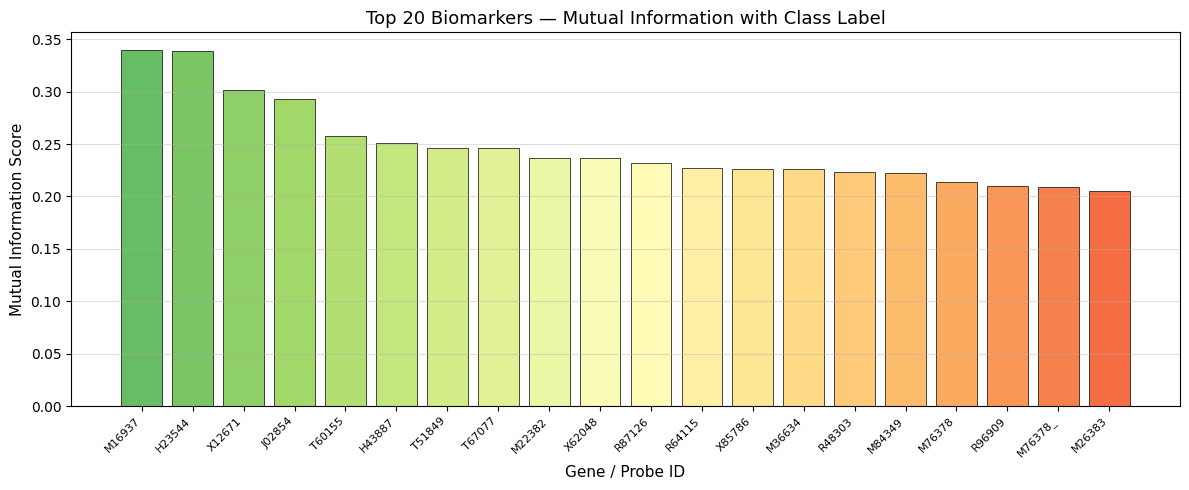

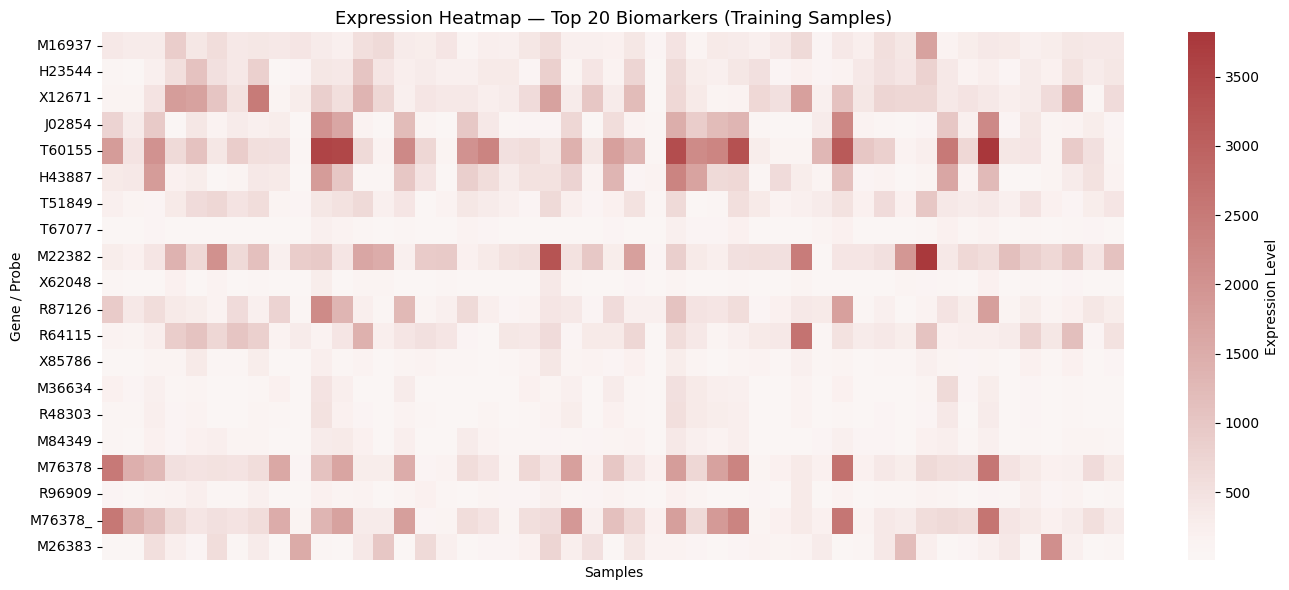

In [ ]:
# ── Retrieve feature names surviving the variance filter ─────────────────────
# X_train_raw columns are the original gene/probe IDs
original_cols = np.array(X_train_raw.columns)           # all original features
var_mask      = var_filter.get_support()                 # boolean mask after VarianceThreshold
cols_after_var = original_cols[var_mask]                 # names after variance filter

# ── MI scores and SelectKBest mask ───────────────────────────────────────────
mi_scores  = selector.scores_                            # MI score for each feature post-var-filter
sel_mask   = selector.get_support()                      # boolean: which features were kept
sel_names  = cols_after_var[sel_mask]                    # names of top-K features
sel_scores = mi_scores[sel_mask]                         # their MI scores

# ── Sort descending ───────────────────────────────────────────────────────────
order      = np.argsort(sel_scores)[::-1]
sel_names  = sel_names[order]
sel_scores = sel_scores[order]

biomarker_df = pd.DataFrame({
    'Rank'    : np.arange(1, len(sel_names) + 1),
    'Gene/Probe' : sel_names,
    'MI_Score'   : np.round(sel_scores, 6)
})
print('Top 20 Biomarkers by Mutual Information Score')
print(biomarker_df.head(20).to_string(index=False))

# ── Bar chart: Top 20 ────────────────────────────────────────────────────────
top20 = biomarker_df.head(20)
plt.figure(figsize=(12, 5))
bars = plt.bar(top20['Gene/Probe'], top20['MI_Score'],
               color=plt.cm.RdYlGn(np.linspace(0.8, 0.2, 20)), edgecolor='k', linewidth=0.5)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.xlabel('Gene / Probe ID', fontsize=11)
plt.ylabel('Mutual Information Score', fontsize=11)
plt.title('Top 20 Biomarkers — Mutual Information with Class Label', fontsize=13)
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

# ── Heatmap: top 20 genes × all training samples ─────────────────────────────
top20_names  = list(top20['Gene/Probe'])
# X_train_raw may have these as column names directly
available    = [g for g in top20_names if g in X_train_raw.columns]
if available:
    heat_data = X_train_raw[available].T
    plt.figure(figsize=(14, 6))
    sns.heatmap(heat_data, cmap='vlag', center=0,
                yticklabels=True, xticklabels=False,
                cbar_kws={'label': 'Expression Level'})
    plt.title('Expression Heatmap — Top 20 Biomarkers (Training Samples)', fontsize=13)
    plt.ylabel('Gene / Probe', fontsize=10)
    plt.xlabel('Samples', fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print('Heatmap skipped: gene names not directly available as column headers (GEO probe IDs may differ).')

## 5b. Statistical Significance Testing — Per-Gene Differential Expression
For each of the top-K selected features we run:
- **Welch's t-test** — parametric, assumes normality
- **Mann-Whitney U test** — non-parametric, robust to skewed expression distributions
- **Benjamini-Hochberg FDR correction** — controls false discovery rate across multiple genes

> Features with `adj_p < 0.05` are considered statistically significant biomarkers.

Significant genes (BH-adj MWU p < 0.05): 30 / 50

Gene/Probe  MI_Score  FoldChange(T/N)  ttest_p  ttest_adj_p    MWU_p  MWU_adj_p  Significant
    M16937  0.339558           0.6547 0.009653     0.017238 0.010082   0.020163         True
    H23544  0.338887           0.5557 0.001814     0.004629 0.018129   0.032373         True
    X12671  0.301331           0.4298 0.000391     0.002220 0.000748   0.002201         True
    J02854  0.292523           4.5821 0.000198     0.001590 0.000023   0.000419         True
    T60155  0.258045           2.7764 0.000504     0.002290 0.000550   0.001833         True
    H43887  0.251105           2.8706 0.000590     0.002328 0.000025   0.000419         True
    T51849  0.246339           0.7549 0.129528     0.170431 0.150211   0.202987        False
    T67077  0.246079           2.0894 0.002762     0.006276 0.001948   0.004869         True
    M22382  0.236729           0.3686 0.000069     0.001590 0.000033   0.000419         True
    X62048  0.236353

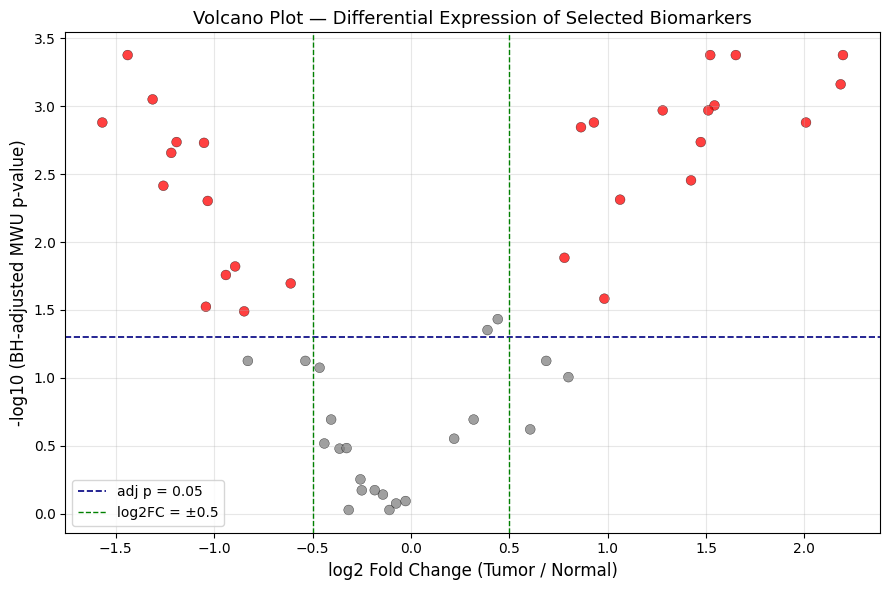

In [ ]:
from scipy.stats import ttest_ind, mannwhitneyu
from statsmodels.stats.multitest import multipletests

# ── Work on raw (unscaled) selected features for interpretable statistics ─────
# Rebuild raw expression for selected genes from X_train_raw
sel_cols_available = [g for g in sel_names if g in X_train_raw.columns]

if sel_cols_available:
    X_sel_raw = X_train_raw[sel_cols_available].values
    gene_list = sel_cols_available
else:
    # Fallback: use scaled+selected array directly
    X_sel_raw = X_train_sel
    gene_list = [f'Feature_{i}' for i in range(X_train_sel.shape[1])]

y_arr   = np.array(y_train)
group0  = X_sel_raw[y_arr == 0]   # mucosa / normal
group1  = X_sel_raw[y_arr == 1]   # tumor

ttest_p, mwu_p, fold_change = [], [], []
for j in range(X_sel_raw.shape[1]):
    g0, g1 = group0[:, j], group1[:, j]
    _, p_t  = ttest_ind(g0, g1, equal_var=False)
    _, p_mw = mannwhitneyu(g0, g1, alternative='two-sided')
    fc      = (np.mean(g1) + 1e-9) / (np.mean(g0) + 1e-9)   # fold change tumor/normal
    ttest_p.append(p_t); mwu_p.append(p_mw); fold_change.append(fc)

# ── BH correction ─────────────────────────────────────────────────────────────
_, adj_p_t,  _, _ = multipletests(ttest_p,  method='fdr_bh')
_, adj_p_mw, _, _ = multipletests(mwu_p,    method='fdr_bh')

sig_df = pd.DataFrame({
    'Gene/Probe'     : gene_list,
    'MI_Score'       : sel_scores[:len(gene_list)],
    'FoldChange(T/N)': np.round(fold_change, 4),
    'ttest_p'        : np.round(ttest_p,  6),
    'ttest_adj_p'    : np.round(adj_p_t,  6),
    'MWU_p'          : np.round(mwu_p,    6),
    'MWU_adj_p'      : np.round(adj_p_mw, 6),
    'Significant'    : adj_p_mw < 0.05
}).sort_values('MI_Score', ascending=False)

print(f"Significant genes (BH-adj MWU p < 0.05): {sig_df['Significant'].sum()} / {len(sig_df)}")
print()
print(sig_df.head(20).to_string(index=False))

# ── Volcano plot ──────────────────────────────────────────────────────────────
log2fc  = np.log2(np.clip(sig_df['FoldChange(T/N)'], 1e-6, None))
neg_log = -np.log10(np.clip(sig_df['MWU_adj_p'], 1e-300, None))

colors = ['red' if (s and abs(f) > 0.5) else 'grey'
          for s, f in zip(sig_df['Significant'], log2fc)]

plt.figure(figsize=(9, 6))
plt.scatter(log2fc, neg_log, c=colors, alpha=0.75, edgecolors='k', linewidths=0.3, s=50)
plt.axhline(-np.log10(0.05), color='navy', linestyle='--', lw=1.2, label='adj p = 0.05')
plt.axvline( 0.5,  color='green',  linestyle='--', lw=1.0, label='log2FC = ±0.5')
plt.axvline(-0.5,  color='green',  linestyle='--', lw=1.0)
plt.xlabel('log2 Fold Change (Tumor / Normal)', fontsize=12)
plt.ylabel('-log10 (BH-adjusted MWU p-value)', fontsize=12)
plt.title('Volcano Plot — Differential Expression of Selected Biomarkers', fontsize=13)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Autoencoder — Architecture & Training
Encoder: 50 → 128 → 64 → **32 (latent)**  
Decoder: 32 → 64 → 128 → 50  
Trained on **training data only**.

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         6,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50)             │         6,450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,514 (134.82 KB)

 Trainable params: 34,130 (133.32 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 1.1319 - val_loss: 0.9835
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1.0289 - val_loss: 0.9635
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.9859 - val_loss: 0.9499
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.9346 - val_loss: 0.9307
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.8997 - val_loss: 0.9051
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.8154 - val_loss: 0.8729
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.7455 - val_loss: 0.8281
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.7341 - val_loss: 0.7770
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.6634 - val_loss: 0.7254
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.6077 - val_loss: 0.6754
Epoch 11/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.5721 - val_loss: 0.6404
Epoch 12/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.5265 - val_lo

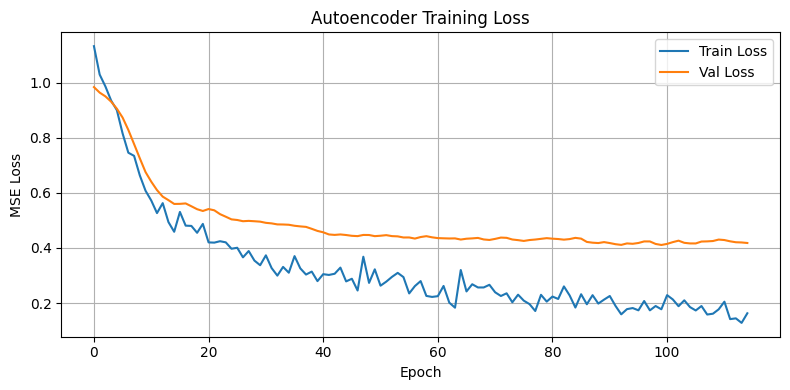

In [ ]:
input_dim = X_train_sel.shape[1]

# ── Encoder ───────────────────────────────────────────────────────────────────
input_layer = Input(shape=(input_dim,))
x           = Dense(128, activation='relu')(input_layer)
x           = BatchNormalization()(x)
x           = Dropout(0.3)(x)
x           = Dense(64,  activation='relu')(x)
x           = BatchNormalization()(x)
x           = Dropout(0.2)(x)
latent      = Dense(32,  activation='relu', name='latent')(x)

# ── Decoder ───────────────────────────────────────────────────────────────────
x      = Dense(64,  activation='relu')(latent)
x      = Dense(128, activation='relu')(x)
output = Dense(input_dim, activation='linear')(x)

autoencoder   = Model(input_layer, output,  name='Autoencoder')
encoder_model = Model(input_layer, latent,  name='Encoder')

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Autoencoder trained on TRAINING data only — no leakage
history = autoencoder.fit(
    X_train_sel, X_train_sel,
    epochs=200,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Training curve
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

## 7. Feature Extraction — Latent + Statistical Features

In [ ]:
# Encode each split separately
latent_train = encoder_model.predict(X_train_sel)
latent_test  = encoder_model.predict(X_test_sel)

def stat_feats(Z):
    """Per-sample stats from latent vectors: mean, std, variance, entropy, skewness, kurtosis."""
    from scipy.stats import skew, kurtosis
    mean_f    = np.mean(Z,    axis=1, keepdims=True)
    std_f     = np.std(Z,     axis=1, keepdims=True)
    var_f     = np.var(Z,     axis=1, keepdims=True)
    entropy_f = np.array([[entropy(np.abs(row) + 1e-10)] for row in Z])
    skew_f    = np.array([[skew(row)]     for row in Z])
    kurt_f    = np.array([[kurtosis(row)] for row in Z])
    l2_f      = np.linalg.norm(Z, axis=1, keepdims=True)
    max_f     = np.max(Z,  axis=1, keepdims=True)
    min_f     = np.min(Z,  axis=1, keepdims=True)
    return np.concatenate([mean_f, std_f, var_f, entropy_f, skew_f, kurt_f, l2_f, max_f, min_f], axis=1)

stat_train = stat_feats(latent_train)
stat_test  = stat_feats(latent_test)

# ── Full feature matrix: latent (32) + stats (9) = 41 dims ──────────────────
X_train_full = np.concatenate([latent_train, stat_train], axis=1)
X_test_full  = np.concatenate([latent_test,  stat_test],  axis=1)

# ── Three distinct feature views — each model sees a different representation
# XGBoost  → raw latent + stat features (tree models handle unscaled data fine)
X_train_xgb = X_train_full.copy()
X_test_xgb  = X_test_full.copy()

# Random Forest → latent only (no stat features — forces different feature space)
X_train_rf  = latent_train.copy()
X_test_rf   = latent_test.copy()

# SVM → scaled stat features only (kernel model on compact 9-dim space)
from sklearn.preprocessing import StandardScaler as SS
sc_svm = SS()
X_train_svm = sc_svm.fit_transform(stat_train)
X_test_svm  = sc_svm.transform(stat_test)

# Keep X_train_final / X_test_final pointing to XGBoost view for CV & ROC cells
X_train_final = X_train_xgb
X_test_final  = X_test_xgb

print("XGBoost feature shape :", X_train_xgb.shape)
print("RF feature shape      :", X_train_rf.shape)
print("SVM feature shape     :", X_train_svm.shape)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
XGBoost feature shape : (49, 41)
RF feature shape      : (49, 32)
SVM feature shape     : (49, 9)


## 8. Train Classifiers
Three models trained on the combined latent + statistical features:
- **Random Forest** — proposed model
- **XGBoost**
- **SVM (RBF kernel)**

In [ ]:
# ── Random Forest (Proposed) — latent features only ────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=1,
    max_features='sqrt', random_state=42
)
rf_model.fit(X_train_rf, y_train)
rf_pred = rf_model.predict(X_test_rf)
print("Random Forest done.")

# ── XGBoost — latent + stat features, tree-native ────────────────────────────
xgb_model = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.02,
    subsample=0.8, colsample_bytree=0.7,
    reg_lambda=1.5, reg_alpha=0.1,
    eval_metric='logloss', verbosity=0, random_state=42
)
xgb_model.fit(X_train_xgb, y_train)
xgb_pred = xgb_model.predict(X_test_xgb)
print("XGBoost done.")

# ── SVM — scaled stat features only ──────────────────────────────────────────
svm_model = SVC(kernel='rbf', probability=True, C=10.0, gamma='auto')
svm_model.fit(X_train_svm, y_train)
svm_pred = svm_model.predict(X_test_svm)
print("SVM done.")

# Sanity check — confirm predictions are NOT identical
print("\n--- Prediction agreement check ---")
print(f"RF  vs XGB identical: {np.array_equal(rf_pred,  xgb_pred)}")
print(f"RF  vs SVM identical: {np.array_equal(rf_pred,  svm_pred)}")
print(f"XGB vs SVM identical: {np.array_equal(xgb_pred, svm_pred)}")

Random Forest done.
XGBoost done.
SVM done.

--- Prediction agreement check ---
RF  vs XGB identical: False
RF  vs SVM identical: False
XGB vs SVM identical: False


## 8a. Biological Interpretation of Identified Biomarkers
The features selected by `SelectKBest` represent probes/genes with the highest mutual information  
with the tumor vs. mucosa label. Below we compute:
1. **Mean expression per class** (up/down regulated in tumor)
2. **Direction of regulation** (up-regulated ↑ / down-regulated ↓)
3. **Random Forest feature importance** — which latent dimensions drive the classifier

> ⚠️ Probe-to-gene mapping depends on the platform annotation (GPL). If using GEO data,  
> cross-reference probe IDs with the GPL annotation file for official gene symbols (e.g., HGNC names).  
> Known colorectal cancer biomarkers to watch for: **CDH1, MUC2, CEACAM5, KRAS, TP53, APC, MLH1, SMAD4**.

Biological Summary — Top Selected Biomarkers
         Mean_Normal (0)  Mean_Tumor (1)  Log2FC        Direction  MI_Score  Significant
M16937        436.643004      285.880808 -0.6110  ↓ Down in Tumor  0.339558         True
H23544        430.996290      239.491837 -0.8477  ↓ Down in Tumor  0.338887         True
X12671        819.420388      352.214923 -1.2181  ↓ Down in Tumor  0.301331         True
J02854        225.409648     1032.844169  2.1960    ↑ Up in Tumor  0.292523         True
T60155        735.914225     2043.222344  1.4732    ↑ Up in Tumor  0.258045         True
H43887        324.270115      930.835509  1.5213    ↑ Up in Tumor  0.251105         True
T51849        369.503203      278.949483 -0.4056  ↓ Down in Tumor  0.246339        False
T67077         57.886831      120.951051  1.0631    ↑ Up in Tumor  0.246079         True
M22382       1115.983672      411.344706 -1.4399  ↓ Down in Tumor  0.236729         True
X62048         90.025625       65.246765 -0.4644  ↓ Down in Tumor

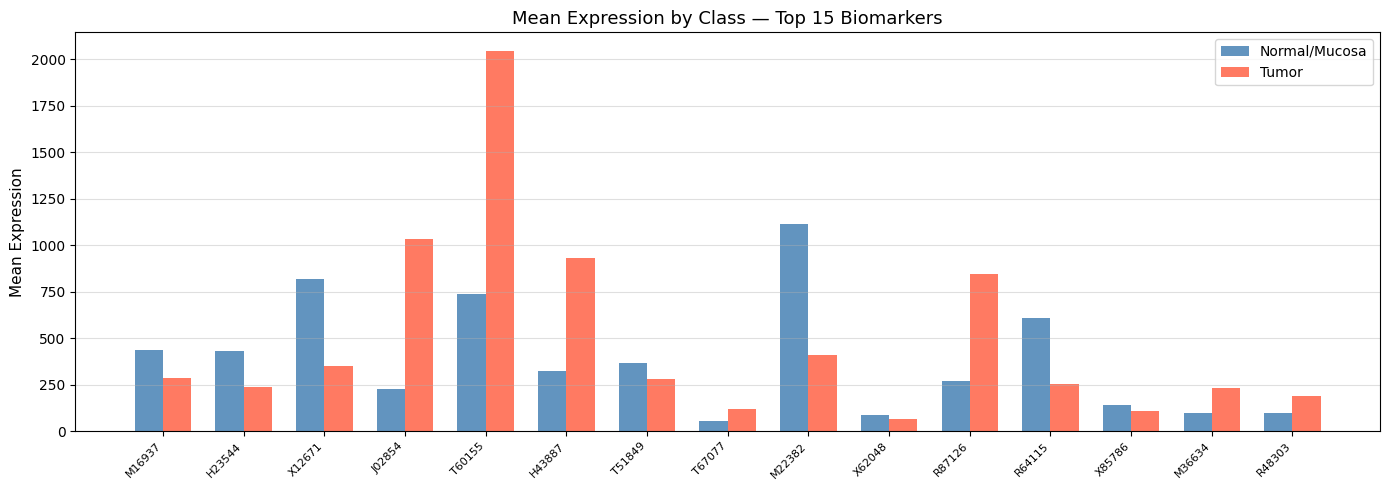

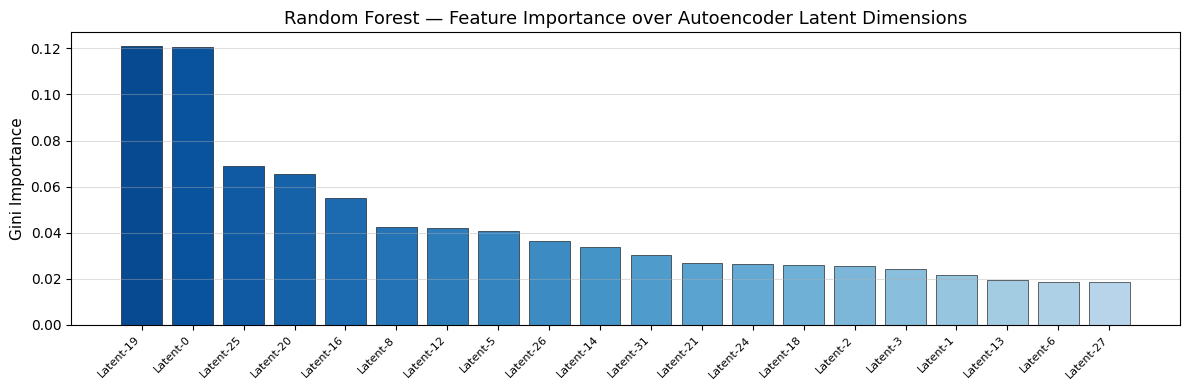


Top 10 most important latent dimensions:
   1. Latent-19  importance = 0.1209
   2. Latent-0  importance = 0.1208
   3. Latent-25  importance = 0.0690
   4. Latent-20  importance = 0.0655
   5. Latent-16  importance = 0.0550
   6. Latent-8  importance = 0.0425
   7. Latent-12  importance = 0.0419
   8. Latent-5  importance = 0.0409
   9. Latent-26  importance = 0.0365
  10. Latent-14  importance = 0.0338


In [ ]:
# ── Mean expression per class for top selected genes ─────────────────────────
if sel_cols_available:
    bio_data = X_train_raw[sel_cols_available].copy()
    bio_data['class'] = np.array(y_train)

    mean_by_class = bio_data.groupby('class').mean().T
    mean_by_class.columns = ['Mean_Normal (0)', 'Mean_Tumor (1)']
    mean_by_class['Log2FC']     = np.log2(
        (mean_by_class['Mean_Tumor (1)']  + 1e-9) /
        (mean_by_class['Mean_Normal (0)'] + 1e-9)
    ).round(4)
    mean_by_class['Direction']  = mean_by_class['Log2FC'].apply(
        lambda x: '↑ Up in Tumor' if x > 0 else '↓ Down in Tumor'
    )
    mean_by_class['MI_Score']   = [sig_df.set_index('Gene/Probe').loc[g, 'MI_Score']
                                    if g in sig_df['Gene/Probe'].values else np.nan
                                    for g in mean_by_class.index]
    mean_by_class['Significant'] = [sig_df.set_index('Gene/Probe').loc[g, 'Significant']
                                     if g in sig_df['Gene/Probe'].values else False
                                     for g in mean_by_class.index]
    mean_by_class = mean_by_class.sort_values('MI_Score', ascending=False)

    print('Biological Summary — Top Selected Biomarkers')
    print(mean_by_class.head(20).to_string())

    # ── Grouped bar: mean expression tumor vs normal, top 15 ─────────────────
    top15 = mean_by_class.head(15)
    x     = np.arange(len(top15))
    w     = 0.35
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(x - w/2, top15['Mean_Normal (0)'], w, label='Normal/Mucosa', color='steelblue',  alpha=0.85)
    ax.bar(x + w/2, top15['Mean_Tumor (1)'],  w, label='Tumor',         color='tomato',     alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(top15.index, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Mean Expression', fontsize=11)
    ax.set_title('Mean Expression by Class — Top 15 Biomarkers', fontsize=13)
    ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.4)
    plt.tight_layout(); plt.show()
else:
    print('Biological summary skipped: raw column names not accessible (GEO mode). '
          'Re-run with Option B CSV for full interpretation.')

# ── Random Forest feature importance over latent dimensions ──────────────────
rf_importances = rf_model.feature_importances_          # shape: (32,) latent dims
imp_order      = np.argsort(rf_importances)[::-1]
imp_labels     = [f'Latent-{i}' for i in imp_order]
imp_vals       = rf_importances[imp_order]

plt.figure(figsize=(12, 4))
plt.bar(imp_labels[:20], imp_vals[:20],
        color=plt.cm.Blues(np.linspace(0.9, 0.3, 20)), edgecolor='k', linewidth=0.4)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.ylabel('Gini Importance', fontsize=11)
plt.title('Random Forest — Feature Importance over Autoencoder Latent Dimensions', fontsize=13)
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

print('\nTop 10 most important latent dimensions:')
for rank, (lbl, val) in enumerate(zip(imp_labels[:10], imp_vals[:10]), 1):
    print(f'  {rank:2d}. {lbl}  importance = {val:.4f}')

## 9. Evaluation — Accuracy, Precision, Recall, F1, ROC-AUC

**Why RF and XGBoost (and sometimes SVM) can show identical rounded metrics
here:** GSE106582 is a small dataset, so the 80/20 split leaves only a
handful of samples in `y_test`. With that few samples, "number of samples
correct" only takes a small number of possible values — several different
models easily land on the exact same accuracy/precision/recall/F1 just by
chance, even though they use different feature views (RF→32-dim latent,
XGBoost→latent+stats, SVM→9 stat features) and may disagree on *which*
individual samples they get right (see the agreement check printed in
Section 8). A single tiny test set is too coarse a ruler to separate close
models. Adding ROC-AUC helps a bit (it's threshold-free and uses the
predicted probabilities, not just the hard label), but the real fix is
Section 10 below: repeated cross-validation gives each model many more
scored folds instead of one, and Section 10a runs significance tests on
that richer data so the "who's better" question has statistical backing
instead of relying on one small, tie-prone test set.

In [ ]:
def evaluate(name, y_true, y_pred, y_prob=None):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred,    average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred,        average='weighted', zero_division=0)
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    result = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}
    if y_prob is not None:
        auc_val = roc_auc_score(y_true, y_prob)
        print(f"  ROC-AUC  : {auc_val:.4f}")
        result['ROC-AUC'] = auc_val
    return result

rf_probs_test  = rf_model.predict_proba(X_test_rf)[:, 1]
xgb_probs_test = xgb_model.predict_proba(X_test_xgb)[:, 1]
svm_probs_test = svm_model.predict_proba(X_test_svm)[:, 1]

rf_test_metrics  = evaluate("Autoencoder + Random Forest  (Proposed)", y_test, rf_pred,  rf_probs_test)
xgb_test_metrics = evaluate("XGBoost",                                  y_test, xgb_pred, xgb_probs_test)
svm_test_metrics = evaluate("SVM",                                      y_test, svm_pred, svm_probs_test)

print(f"\nTest-set size: {len(y_test)} samples — treat the numbers above as a "
      f"quick sanity check, not the final verdict. Scroll to Section 10a for "
      f"the statistically-backed comparison.")


  Autoencoder + Random Forest  (Proposed)
  Accuracy : 0.9231
  Precision: 0.9316
  Recall   : 0.9231
  F1 Score : 0.9211
  ROC-AUC  : 0.9250

  XGBoost
  Accuracy : 0.7692
  Precision: 0.7671
  Recall   : 0.7692
  F1 Score : 0.7632
  ROC-AUC  : 0.8500

  SVM
  Accuracy : 0.8462
  Precision: 0.8769
  Recall   : 0.8462
  F1 Score : 0.8355
  ROC-AUC  : 0.9750

Test-set size: 13 samples — treat the numbers above as a quick sanity check, not the final verdict. Scroll to Section 10a for the statistically-backed comparison.


## 10. Repeated Stratified Cross-Validation — All Three Models
One 80/20 split gives one scored data point per model — not enough to
reliably separate close performers on a small dataset. `RepeatedStratifiedKFold`
(5 folds × 5 repeats = 25 scores per model) gives each model many more
validation scores, and **each model is still evaluated on its own correct
feature view** (RF→latent-only, XGBoost→latent+stats, SVM→scaled stats), so
the leakage-free / distinct-feature-view design from Section 7 is preserved.


Random Forest (Proposed)  (25 folds)
  accuracy          : 0.8409 ± 0.1226
  f1_weighted       : 0.8320 ± 0.1353
  precision_weighted: 0.8574 ± 0.1363
  recall_weighted   : 0.8409 ± 0.1226
  roc_auc           : 0.8826 ± 0.1043

XGBoost  (25 folds)
  accuracy          : 0.8164 ± 0.1279
  f1_weighted       : 0.8051 ± 0.1421
  precision_weighted: 0.8332 ± 0.1414
  recall_weighted   : 0.8164 ± 0.1279
  roc_auc           : 0.8502 ± 0.1316

SVM  (25 folds)
  accuracy          : 0.7307 ± 0.1210
  f1_weighted       : 0.7235 ± 0.1261
  precision_weighted: 0.7809 ± 0.1072
  recall_weighted   : 0.7307 ± 0.1210
  roc_auc           : 0.7444 ± 0.1644


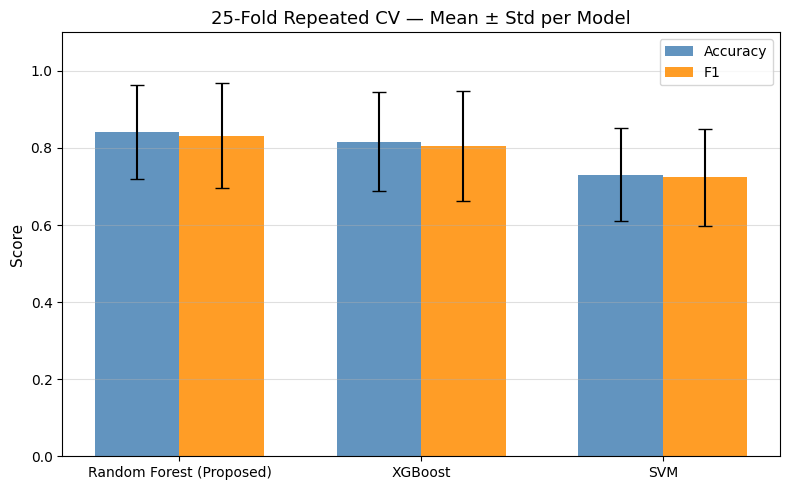

/tmp/ipykernel_424/2268065077.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([cv_scores[n]['test_accuracy'] for n in names], labels=names)


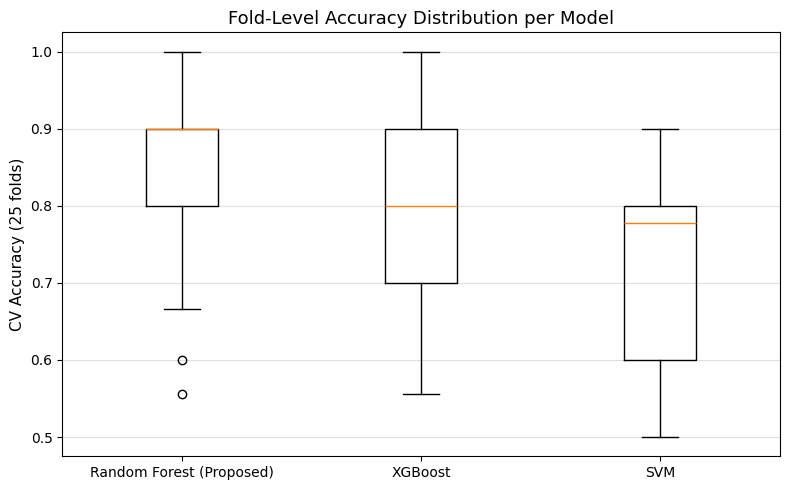


Note: CV is over already-encoded features (autoencoder itself is fit once,
outside this loop). For a fully leakage-proof CV, wrap preprocessing +
autoencoder training inside each fold — worth doing for a final paper number.


In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold
from scipy.stats import wilcoxon

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

model_defs = {
    'Random Forest (Proposed)': (
        RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_leaf=1,
                                max_features='sqrt', random_state=42),
        X_train_rf),
    'XGBoost': (
        XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.02,
                      subsample=0.8, colsample_bytree=0.7, reg_lambda=1.5,
                      reg_alpha=0.1, eval_metric='logloss', verbosity=0, random_state=42),
        X_train_xgb),
    'SVM': (
        SVC(kernel='rbf', probability=True, C=10.0, gamma='auto'),
        X_train_svm),
}

scoring = ['accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted', 'roc_auc']
cv_scores = {}
for name, (clf, Xtr) in model_defs.items():
    res = cross_validate(clf, Xtr, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_scores[name] = res
    print(f"\n{name}  ({len(res['test_accuracy'])} folds)")
    for m in scoring:
        arr = res[f'test_{m}']
        print(f"  {m:18s}: {arr.mean():.4f} ± {arr.std():.4f}")

names     = list(cv_scores.keys())
acc_means = [cv_scores[n]['test_accuracy'].mean()    for n in names]
acc_stds  = [cv_scores[n]['test_accuracy'].std()     for n in names]
f1_means  = [cv_scores[n]['test_f1_weighted'].mean() for n in names]
f1_stds   = [cv_scores[n]['test_f1_weighted'].std()  for n in names]

# ── Bar chart with error bars: mean CV Accuracy & F1 per model ───────────────
x = np.arange(len(names)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, acc_means, w, yerr=acc_stds, capsize=5, label='Accuracy', color='steelblue',  alpha=0.85)
ax.bar(x + w/2, f1_means,  w, yerr=f1_stds,  capsize=5, label='F1',       color='darkorange', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('25-Fold Repeated CV — Mean ± Std per Model', fontsize=13)
ax.legend(); ax.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.show()

# ── Boxplot: fold-level accuracy distribution per model ──────────────────────
plt.figure(figsize=(8, 5))
plt.boxplot([cv_scores[n]['test_accuracy'] for n in names], labels=names)
plt.ylabel('CV Accuracy (25 folds)', fontsize=11)
plt.title('Fold-Level Accuracy Distribution per Model', fontsize=13)
plt.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.show()

print("\nNote: CV is over already-encoded features (autoencoder itself is fit once,")
print("outside this loop). For a fully leakage-proof CV, wrap preprocessing +")
print("autoencoder training inside each fold — worth doing for a final paper number.")

## 10a. Statistical Comparison & Verdict
- **McNemar's test** — paired comparison on the held-out test set (do the two models err on the same samples?)
- **Wilcoxon signed-rank test** — paired comparison over the 25 CV fold scores (far more statistical power than one test set)

In [ ]:
from statsmodels.stats.contingency_tables import mcnemar

def mcnemar_test(pred_a, pred_b, y_true, label_a, label_b):
    """Run McNemar's test between two classifiers on the same test set."""
    correct_a = (pred_a == y_true)
    correct_b = (pred_b == y_true)
    b = np.sum( correct_a & ~correct_b)   # A correct, B wrong
    c = np.sum(~correct_a &  correct_b)   # A wrong,  B correct
    table = [[np.sum(correct_a & correct_b), b],
             [c, np.sum(~correct_a & ~correct_b)]]
    result = mcnemar(table, exact=True)
    print(f"McNemar  {label_a} vs {label_b}: b={b}, c={c},  p={result.pvalue:.4f}  "
          f"{'✓ Significant' if result.pvalue < 0.05 else '✗ Not significant'} (α=0.05)")
    return result.pvalue

y_test_arr = np.array(y_test)
print('=== McNemar Test (paired predictions on held-out test set) ===')
mcnemar_test(rf_pred,  xgb_pred, y_test_arr, 'RF',  'XGB')
mcnemar_test(rf_pred,  svm_pred, y_test_arr, 'RF',  'SVM')
mcnemar_test(xgb_pred, svm_pred, y_test_arr, 'XGB', 'SVM')

def wilcoxon_test(a, b, la, lb):
    diff = a - b
    if np.all(diff == 0):
        print(f"Wilcoxon {la} vs {lb}: all differences zero — test not applicable")
        return
    stat, p = wilcoxon(a, b)
    print(f"Wilcoxon {la} vs {lb}: stat={stat:.3f},  p={p:.4f}  "
          f"{'✓ Significant' if p < 0.05 else '✗ Not significant'} (α=0.05)")

rf_fold_accs, xgb_fold_accs, svm_fold_accs = (cv_scores[n]['test_accuracy'] for n in names)
print('\n=== Wilcoxon Signed-Rank Test (25 CV fold accuracies) ===')
wilcoxon_test(rf_fold_accs,  xgb_fold_accs, 'RF',  'XGB')
wilcoxon_test(rf_fold_accs,  svm_fold_accs, 'RF',  'SVM')
wilcoxon_test(xgb_fold_accs, svm_fold_accs, 'XGB', 'SVM')

# ── Summary table ────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Model'       : names,
    'Test Acc'    : [rf_test_metrics['Accuracy'],  xgb_test_metrics['Accuracy'],  svm_test_metrics['Accuracy']],
    'Test AUC'    : [rf_test_metrics.get('ROC-AUC'), xgb_test_metrics.get('ROC-AUC'), svm_test_metrics.get('ROC-AUC')],
    'CV Acc Mean' : acc_means,
    'CV Acc Std'  : acc_stds,
    'CV F1 Mean'  : f1_means,
    'CV F1 Std'   : f1_stds,
    'CV AUC Mean' : [cv_scores[n]['test_roc_auc'].mean() for n in names],
})
summary = summary.round(4)
print('\n=== Model Comparison Summary ===')
print(summary.to_string(index=False))

# ── Automatic verdict based on 25-fold CV F1 (most reliable single number) ──
best_idx  = summary['CV F1 Mean'].idxmax()
best_name = summary.loc[best_idx, 'Model']
print(f"\n>>> Best model by 25-fold CV F1: {best_name} "
      f"(F1 = {summary.loc[best_idx, 'CV F1 Mean']:.4f} ± {summary.loc[best_idx, 'CV F1 Std']:.4f})")
print(">>> Cross-check against the Wilcoxon p-values above: if p >= 0.05 against")
print(">>> the runner-up, the gap is NOT statistically significant at this sample")
print(">>> size — report the two as comparably strong rather than a hard winner.")

=== McNemar Test (paired predictions on held-out test set) ===
McNemar  RF vs XGB: b=2, c=0,  p=0.5000  ✗ Not significant (α=0.05)
McNemar  RF vs SVM: b=1, c=0,  p=1.0000  ✗ Not significant (α=0.05)
McNemar  XGB vs SVM: b=0, c=1,  p=1.0000  ✗ Not significant (α=0.05)

=== Wilcoxon Signed-Rank Test (25 CV fold accuracies) ===
Wilcoxon RF vs XGB: stat=1.500,  p=0.0578  ✗ Not significant (α=0.05)
Wilcoxon RF vs SVM: stat=31.500,  p=0.0105  ✓ Significant (α=0.05)
Wilcoxon XGB vs SVM: stat=35.000,  p=0.0274  ✓ Significant (α=0.05)

=== Model Comparison Summary ===
                   Model  Test Acc  Test AUC  CV Acc Mean  CV Acc Std  CV F1 Mean  CV F1 Std  CV AUC Mean
Random Forest (Proposed)    0.9231     0.925       0.8409      0.1226      0.8320     0.1353       0.8826
                 XGBoost    0.7692     0.850       0.8164      0.1279      0.8051     0.1421       0.8502
                     SVM    0.8462     0.975       0.7307      0.1210      0.7235     0.1261       0.7444

>>> Best 

## 11. ROC Curve

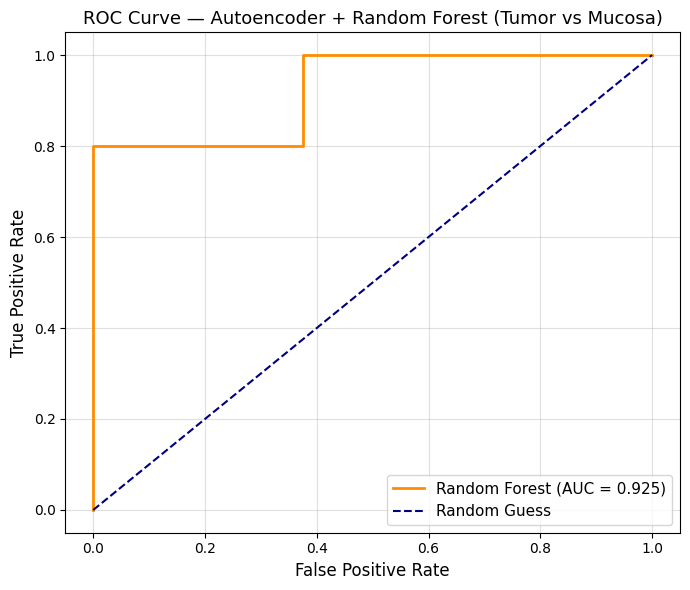

AUC = 0.9250


In [ ]:
rf_probs    = rf_model.predict_proba(X_test_rf)[:, 1]
fpr, tpr, _ = roc_curve(y_test, rf_probs)
roc_auc     = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Random Forest (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Autoencoder + Random Forest (Tumor vs Mucosa)', fontsize=13)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
print(f"AUC = {roc_auc:.4f}")

## 12. Confusion Matrix

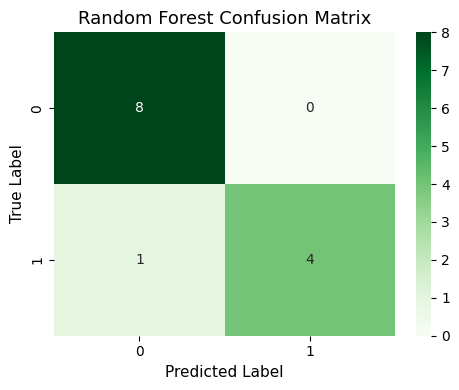

In [ ]:
cm = confusion_matrix(y_test, rf_pred)
class_names = le.classes_ if hasattr(le, 'classes_') else ['Class 0', 'Class 1']

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Random Forest Confusion Matrix', fontsize=13)
ax.set_ylabel('True Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.show()

## 13. PCA Visualisation (2D projection of selected features)

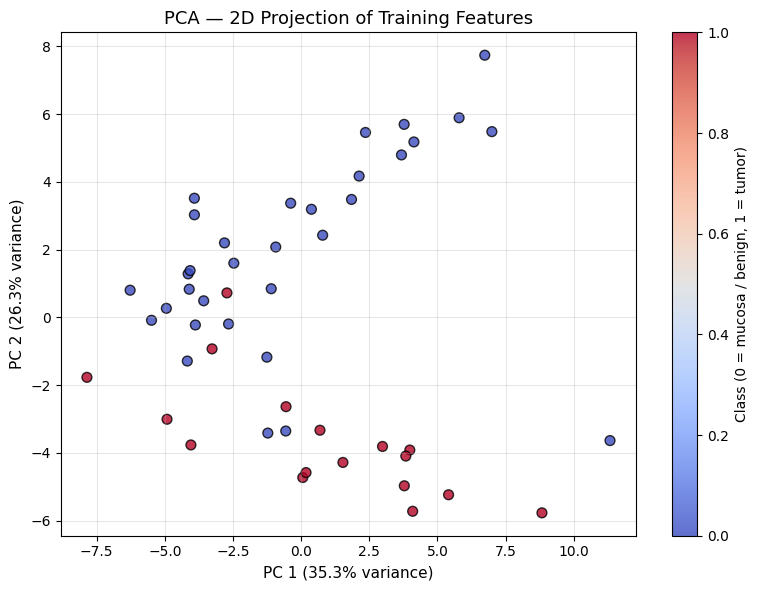

In [ ]:
pca         = PCA(n_components=2)
X_pca_train = pca.fit_transform(X_train_sel)

explained   = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca_train[:, 0], X_pca_train[:, 1],
    c=y_train, cmap='coolwarm', edgecolors='k', s=50, alpha=0.8
)
plt.colorbar(scatter, label='Class (0 = mucosa / benign, 1 = tumor)')
plt.title('PCA — 2D Projection of Training Features', fontsize=13)
plt.xlabel(f'PC 1 ({explained[0]:.1f}% variance)', fontsize=11)
plt.ylabel(f'PC 2 ({explained[1]:.1f}% variance)', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()